In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensoflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 40
DATA_DIR='plantvillage/'

# Data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    'plantvillage/',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'plantvillage/',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Build transfer learning model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Save best model and stop early if not improving
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


ImportError: Traceback (most recent call last):
  File "C:\Users\Mishika\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [9]:
model.save("mobilenetv2_model.h5")


In [10]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np


In [12]:
import os
import random
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("model.h5")  # or .keras

# Define path to one of your class folders
folder_path = "C:/Users/Mishika/Desktop/Tomato Disease/training/plantvillage/Tomato___Late_blight"  # change to your class folder

# Pick a random image file
image_file = random.choice(os.listdir(folder_path))
img_path = os.path.join(folder_path, image_file)

# Load and preprocess image
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Class names as per your folder order (update if needed)
class_names = ["Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___healthy"]

print("📸 Image:", image_file)
print("✅ Predicted class:", class_names[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
📸 Image: c03b8994-6c6e-4997-83fd-803f3cc580ad___GHLB2 Leaf 8833.JPG
✅ Predicted class: Tomato___Late_blight


Class labels: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


C:\Users\Mishika\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Mishika\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


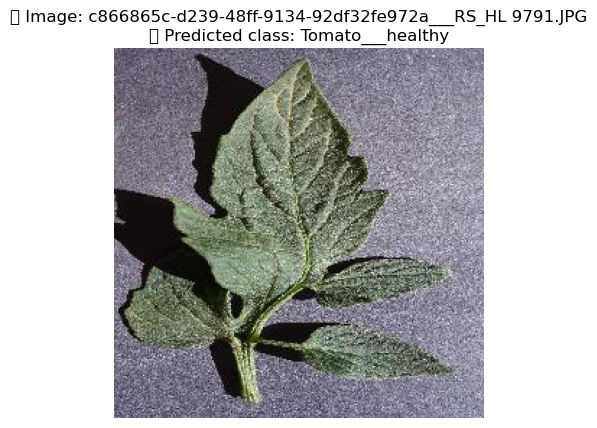

In [13]:
import os
import random
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

#   Paths 
model_path = 'model.h5'  
image_folder_path = r'C:\Users\Mishika\Desktop\tomato disease\training\plantvillage'  # path to parent folder containing class subfolders

#  Load Model 
model = load_model(model_path)

#  Class Labels (update based on your folders/classes) 
class_labels = os.listdir(image_folder_path)
print("Class labels:", class_labels)

#  Random Image Selection 
selected_class = random.choice(class_labels)
class_folder = os.path.join(image_folder_path, selected_class)
image_file = random.choice(os.listdir(class_folder))
image_path = os.path.join(class_folder, image_file)

#  Load and Preprocess Image 
img = load_img(image_path, target_size=(224, 224))  # Change size if needed
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
predicted_class = class_labels[np.argmax(pred)]

#  Show Image and Result 
plt.imshow(load_img(image_path))
plt.title(f"📸 Image: {image_file}\n✅ Predicted class: {predicted_class}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


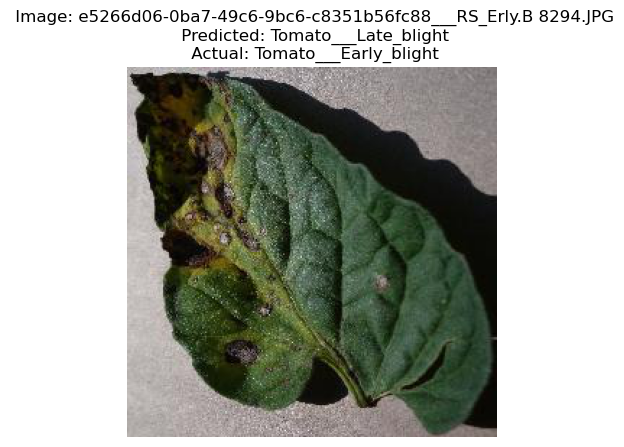


 File: e5266d06-0ba7-49c6-9bc6-c8351b56fc88___RS_Erly.B 8294.JPG
 Predicted Class: Tomato___Late_blight
 Actual Class: Tomato___Early_blight


In [14]:
import os
import random
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# --- Paths ---
model_path = 'model.h5'  # or 'model.keras'
image_folder_path = r'C:\Users\Mishika\Desktop\tomato disease\training\plantvillage'  # folder with class-wise subfolders

# --- Load Model ---
model = load_model(model_path)

# --- Class Labels ---
class_labels = sorted(os.listdir(image_folder_path))  # sorted for consistent order

# --- Select Random Image ---
actual_class = random.choice(class_labels)
class_folder = os.path.join(image_folder_path, actual_class)
image_file = random.choice(os.listdir(class_folder))
image_path = os.path.join(class_folder, image_file)

# --- Load & Preprocess Image ---
img = load_img(image_path, target_size=(224, 224))  # match your model input size
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# --- Predict ---
pred = model.predict(img_array)
predicted_class = class_labels[np.argmax(pred)]

# --- Show Result ---
plt.imshow(load_img(image_path))
plt.title(f" Image: {image_file}\n Predicted: {predicted_class}\n Actual: {actual_class}")
plt.axis('off')
plt.show()

# --- Optional Console Output ---
print(f"\n File: {image_file}")
print(f" Predicted Class: {predicted_class}")
print(f" Actual Class: {actual_class}")


In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 40
DATA_DIR = 'plantvillage/'

# Create tf.data.Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
).prefetch(buffer_size=tf.data.AUTOTUNE)

# Data Augmentation (as a tf.data.Dataset map function)
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_rotation(image, factor=0.2)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

train_dataset_augmented = train_dataset.map(augment)

# Build transfer learning model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), alpha=1.0) # You can try smaller alpha
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'), # Reduced Dense layer size
    layers.Dropout(0.3),
    layers.Dense(train_dataset.class_names.__len__(), activation='softmax')
])

# Compile with learning rate scheduling
lr_scheduler = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=train_dataset.cardinality().numpy() * 10 // BATCH_SIZE, # Decay every 10 epochs
    decay_rate=0.9
)
optimizer = Adam(learning_rate=lr_scheduler)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Save best model and stop early if not improving
callbacks = [
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train
history = model.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

C:\Users\Mishika\anaconda3\Lib\site-packages\scipy\__init__.py:143: UserWarning: A NumPy version >=1.19.5 and <1.27.0 is required for this version of SciPy (detected version 2.2.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Mishika\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Mishika\anaconda3\Lib\s

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Mishika\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Mishika\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Mishika\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io_loop.start()
  File "C:\Users\Mishika\anaconda3\Lib\si

AttributeError: _ARRAY_API not found

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject